# 基于背景减除法的动态车辆荷载监测

**关键词：** 背景减除法、高斯混合模型（MOG2）、动态称重（WIM）、桥梁健康监测、计算机视觉

---

## 1. 引言

动态车辆荷载监测在**桥梁健康监测（Structural Health Monitoring, SHM）** 和 **智能交通系统（Intelligent Transportation Systems, ITS）** 中扮演着至关重要的角色。传统的动态称重系统（Weigh-In-Motion, WIM）通常依赖于埋设在路面下的传感器（如压电传感器、光纤光栅传感器等），存在安装维护成本高、影响交通以及寿命有限等问题。

近年来，随着计算机视觉技术的快速发展，基于视频图像的**非接触式视觉动态称重方法（Vision-based WIM, V-WIM）**逐渐成为研究热点。该方法通过架设在桥梁或道路旁的摄像机，从视频流中提取运动车辆的时空信息（速度、轴距、过桥时刻），再结合桥梁结构传感器的动态响应数据，通过反演算法估算车辆动态轴重。

在视觉监测中，准确地从视频流中**分割出运动的车辆**是后续所有工作的基础。**背景减除法（Background Subtraction）**作为一种经典的运动目标检测技术，因其计算效率高、能够获取完整的车辆轮廓，被广泛应用于交通监控场景。本文将详细探讨背景减除法的基本原理，并结合 Python 和 OpenCV 提供完整的代码实现示例。

---

## 2. 动态车辆荷载监测（V-WIM）系统框架

基于计算机视觉的动态车辆荷载监测系统通常包括以下几个核心模块，背景减除法主要服务于第一个模块：

| 模块 | 主要任务 | 关键技术 |
|------|----------|----------|
| **车辆检测与跟踪** | 从视频流中提取运动车辆，追踪轨迹 | 背景减除法、YOLO、DeepSORT |
| **时空信息提取** | 计算车速、轴距、过桥时刻 | 相机标定、透视变换、虚拟线圈 |
| **结构响应采集** | 同步采集桥梁应变、加速度等信号 | 应变计、加速度计、数据采集系统 |
| **荷载反演** | 由结构响应反推车辆动态轴重 | Moses算法、移动荷载识别理论 |

---

## 3. 背景减除法原理

背景减除法的核心思想是：**建立一个静态场景的背景模型，然后将当前帧图像与背景模型进行比较，通过设定阈值来区分前景（运动目标）和背景。**

### 3.1 帧差法（Frame Differencing）

最简单的背景减除是帧差法，即直接计算相邻两帧的像素差值。若差值超过阈值 $T$，则判定为前景：

$$D_t(x, y) = |I_t(x, y) - I_{t-1}(x, y)| > T$$

其中，$I_t$ 和 $I_{t-1}$ 分别是当前帧和前一帧的像素灰度值。帧差法计算极快，但无法提取完整的车辆轮廓，容易在目标内部产生'空洞'，且对缓慢移动的目标检测效果差。

### 3.2 高斯混合模型（MOG2）——自适应背景建模

为了克服复杂交通场景中的**光照渐变、树叶摇晃、摄像机抖动以及车辆阴影**等干扰，目前最常用且鲁棒的背景建模方法是**高斯混合模型（Gaussian Mixture Model, GMM）**。OpenCV 中实现了其改进版本 **MOG2**。

**核心思想：** 不使用单一数值表示背景像素，而是为每个像素点维护由 $K$ 个（通常 $K = 3 \sim 5$）高斯分布组成的混合模型，以适应背景的多模态变化。

**概率密度函数：** 像素 $X_t$ 在时间 $t$ 的概率密度为：

$$P(X_t) = \sum_{i=1}^{K} \omega_{i,t} \cdot \eta(X_t,\, \mu_{i,t},\, \Sigma_{i,t})$$

其中，$\omega_{i,t}$ 是第 $i$ 个高斯分布的权重，$\mu_{i,t}$ 是均值，$\Sigma_{i,t}$ 是协方差矩阵，$\eta$ 是高斯概率密度函数。

**模型更新机制：**

- **匹配成功：** 新像素值落在某个高斯分布的 $2.5\sigma$ 范围内，则更新该分布的均值、方差和权重。
- **匹配失败：** 新像素值不符合任何现有分布，则用新的高斯分布替换权重最小的分布。

**前景判定：** 按 $\omega / \sigma$ 比值对 $K$ 个分布排序，选取前若干个作为背景模型。若当前像素不符合背景分布，则判定为**前景（运动车辆）**。

**阴影检测：** MOG2 还内置了阴影检测功能。若某像素被判定为前景，但其颜色特征（在 HSV 色彩空间下）与背景仅存在亮度差异而色度相似，则将其标记为**阴影**（掩码值为 127，而非 255）。消除阴影对于准确提取车辆轮廓至关重要。

### 3.3 三种方法对比

| 方法 | 计算速度 | 光照适应性 | 阴影处理 | 轮廓完整性 | 适用场景 |
|------|----------|------------|----------|------------|----------|
| 帧差法 | 极快 | 一般 | 无 | 差（有空洞） | 简单场景、快速运动 |
| 单高斯模型 | 快 | 较好 | 无 | 一般 | 背景单一、光照稳定 |
| **MOG2（混合高斯）** | **中等** | **强** | **有** | **好** | **复杂交通场景（推荐）** |
| KNN 背景减除 | 中等 | 强 | 有 | 好 | 场景变化剧烈 |

---

## 4. Python 代码实现

下面我们将使用 Python 和 OpenCV 库，演示如何利用 MOG2 背景减除法从视频中提取运动车辆，并进行轮廓检测与车辆计数。

### 4.1 环境准备与依赖导入

In [1]:
# 安装依赖（如已安装可跳过）
# !pip install opencv-python-headless numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# 设置中文字体支持（可选）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f'OpenCV 版本: {cv2.__version__}')
print(f'NumPy 版本: {np.__version__}')
print('环境准备完毕。')

OpenCV 版本: 5.0.0
NumPy 版本: 2.5.2
环境准备完毕。


### 4.2 生成模拟交通视频帧

为了在无需真实视频文件的情况下演示算法，我们生成一组模拟交通场景的合成帧：包含一辆向右行驶的车辆、随机噪声以及模拟阴影。

findfont: Failed to find font weight bold, now using 400.


成功生成 40 帧模拟交通场景
帧尺寸: 640 x 360 像素


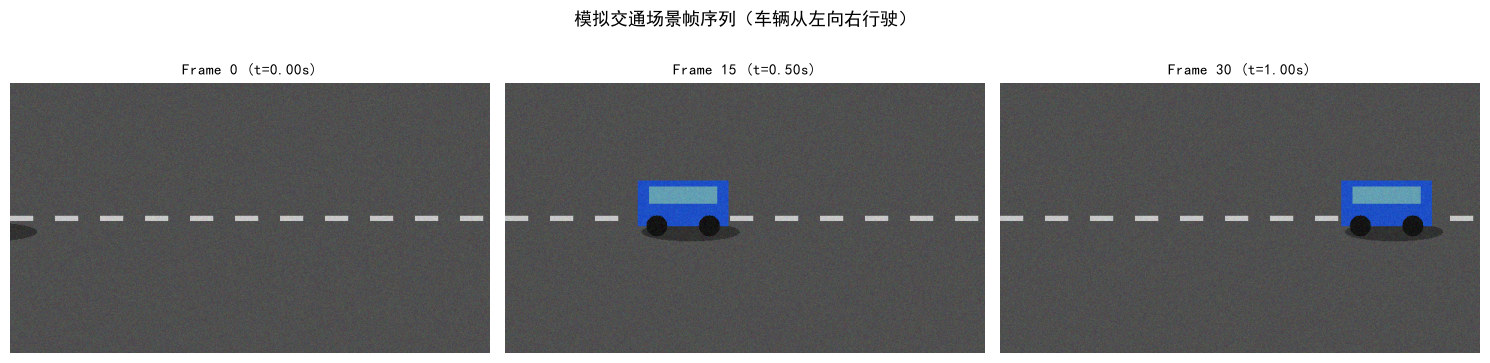

In [2]:
def create_synthetic_traffic_frames(n_frames=40, width=640, height=360):
    """
    生成模拟交通场景的合成帧序列。

    场景描述：
    - 灰色路面背景
    - 一辆蓝色车辆从左向右匀速行驶
    - 车辆下方有半透明阴影
    - 背景中有轻微的随机噪声（模拟光照波动）
    """
    frames = []

    # 创建基础背景：灰色路面 + 白色车道线
    background = np.zeros((height, width, 3), dtype=np.uint8)
    background[:] = (80, 80, 80)  # 深灰色路面
    # 绘制车道线（白色虚线）
    for x in range(0, width, 60):
        cv2.rectangle(background, (x, height//2 - 3), (x + 30, height//2 + 3), (200, 200, 200), -1)

    for i in range(n_frames):
        frame = background.copy()

        # 车辆位置（匀速向右移动）
        car_x = int(-100 + i * (width + 100) / n_frames)
        car_y = height // 2 - 50
        car_w, car_h = 120, 60

        # 绘制车辆阴影（半透明深色区域，偏移车辆位置）
        shadow_overlay = frame.copy()
        cv2.ellipse(shadow_overlay,
                    (car_x + car_w//2 + 10, car_y + car_h + 8),
                    (car_w//2 + 5, 12), 0, 0, 360, (30, 30, 30), -1)
        frame = cv2.addWeighted(shadow_overlay, 0.6, frame, 0.4, 0)

        # 绘制车辆主体（橙红色矩形）
        if 0 <= car_x < width:
            cv2.rectangle(frame, (car_x, car_y), (car_x + car_w, car_y + car_h), (200, 80, 30), -1)
            # 车窗（浅色）
            cv2.rectangle(frame, (car_x + 15, car_y + 8), (car_x + car_w - 15, car_y + 30), (180, 160, 100), -1)
            # 车轮（黑色圆形）
            cv2.circle(frame, (car_x + 25, car_y + car_h), 14, (20, 20, 20), -1)
            cv2.circle(frame, (car_x + car_w - 25, car_y + car_h), 14, (20, 20, 20), -1)

        # 添加随机噪声（模拟光照波动）
        noise = np.random.randint(-15, 15, (height, width, 3))
        frame = np.clip(frame.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        frames.append(frame)

    return frames


# 生成 40 帧模拟视频
synthetic_frames = create_synthetic_traffic_frames(n_frames=40)
print(f'成功生成 {len(synthetic_frames)} 帧模拟交通场景')
print(f'帧尺寸: {synthetic_frames[0].shape[1]} x {synthetic_frames[0].shape[0]} 像素')

# 展示前3帧
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    frame_idx = i * 15
    ax.imshow(cv2.cvtColor(synthetic_frames[frame_idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {frame_idx} (t={frame_idx/30:.2f}s)', fontsize=11)
    ax.axis('off')
plt.suptitle('模拟交通场景帧序列（车辆从左向右行驶）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 MOG2 背景减除核心实现

下面实现完整的背景减除处理流程，包含以下步骤：

1. **应用 MOG2** 获取原始前景掩码（含阴影标记）
2. **消除阴影** 只保留真实车辆前景
3. **形态学后处理** 去除噪声、填补轮廓空洞
4. **轮廓检测与边界框提取** 定位车辆位置

In [3]:
class VehicleDetector:
    """
    基于 MOG2 背景减除法的车辆检测器。

    参数说明：
    ----------
    history : int
        用于建立背景模型的历史帧数。值越大，背景模型越稳定，
        但对场景变化的适应速度越慢。
    var_threshold : float
        像素是否属于背景的方差阈值。值越大，对噪声越不敏感，
        但可能漏检颜色与背景相近的车辆。
    detect_shadows : bool
        是否启用阴影检测。建议开启以获得更准确的车辆轮廓。
    min_area : int
        有效车辆轮廓的最小面积（像素平方），用于过滤噪声。
    """

    def __init__(self, history=300, var_threshold=40, detect_shadows=True, min_area=800):
        # 初始化 MOG2 背景减除器
        self.backSub = cv2.createBackgroundSubtractorMOG2(
            history=history,
            varThreshold=var_threshold,
            detectShadows=detect_shadows
        )
        self.min_area = min_area

        # 形态学操作核：椭圆形，用于自然形状的腐蚀/膨胀
        self.kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        self.kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))

        # 记录检测历史
        self.frame_count = 0

    def process(self, frame):
        """
        处理单帧图像，返回检测结果。

        返回：
        ------
        result_frame : ndarray  - 绘制了检测框的原始帧
        raw_mask     : ndarray  - MOG2 原始掩码（含阴影标记127）
        clean_mask   : ndarray  - 形态学处理后的清洁掩码
        vehicles     : list     - 检测到的车辆列表
        """
        self.frame_count += 1

        # --- 步骤 1：应用 MOG2 背景减除 ---
        # 输出：255=前景, 127=阴影, 0=背景
        raw_mask = self.backSub.apply(frame)

        # --- 步骤 2：消除阴影，只保留真实前景 ---
        # 将阴影（127）归为背景（0），只保留255的真实前景
        _, fg_mask = cv2.threshold(raw_mask, 254, 255, cv2.THRESH_BINARY)

        # --- 步骤 3：形态学后处理 ---
        # 开运算（先腐蚀后膨胀）：去除背景中的小白点噪声
        clean_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, self.kernel_open)
        # 闭运算（先膨胀后腐蚀）：填补车辆内部的黑洞，使轮廓更完整
        clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, self.kernel_close)

        # --- 步骤 4：寻找轮廓并提取车辆边界框 ---
        contours, _ = cv2.findContours(
            clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        result_frame = frame.copy()
        vehicles = []

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > self.min_area:
                x, y, w, h = cv2.boundingRect(cnt)
                # 宽高比过滤：车辆通常宽大于高
                aspect_ratio = w / (h + 1e-6)
                if 0.5 < aspect_ratio < 6.0:
                    vehicles.append({'bbox': (x, y, w, h), 'area': area, 'center': (x + w//2, y + h//2)})

                    # 绘制检测结果
                    cv2.rectangle(result_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                    cv2.circle(result_frame, (x + w//2, y + h//2), 5, (0, 0, 255), -1)
                    label = f'Vehicle | Area:{area:.0f}'
                    cv2.putText(result_frame, label, (x, y - 8),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        return result_frame, raw_mask, clean_mask, vehicles


# 实例化检测器
detector = VehicleDetector(history=300, var_threshold=40, detect_shadows=True, min_area=800)

# 处理所有合成帧
all_results = []
for frame in synthetic_frames:
    result = detector.process(frame)
    all_results.append(result)

print(f'处理完成，共 {len(all_results)} 帧')

# 统计各帧检测到的车辆数
detection_counts = [len(r[3]) for r in all_results]
print(f'各帧检测车辆数: {detection_counts}')

处理完成，共 40 帧
各帧检测车辆数: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


### 4.4 可视化：背景减除各处理阶段对比

下面展示第 25 帧（车辆位于画面中央）的完整处理流程可视化。

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


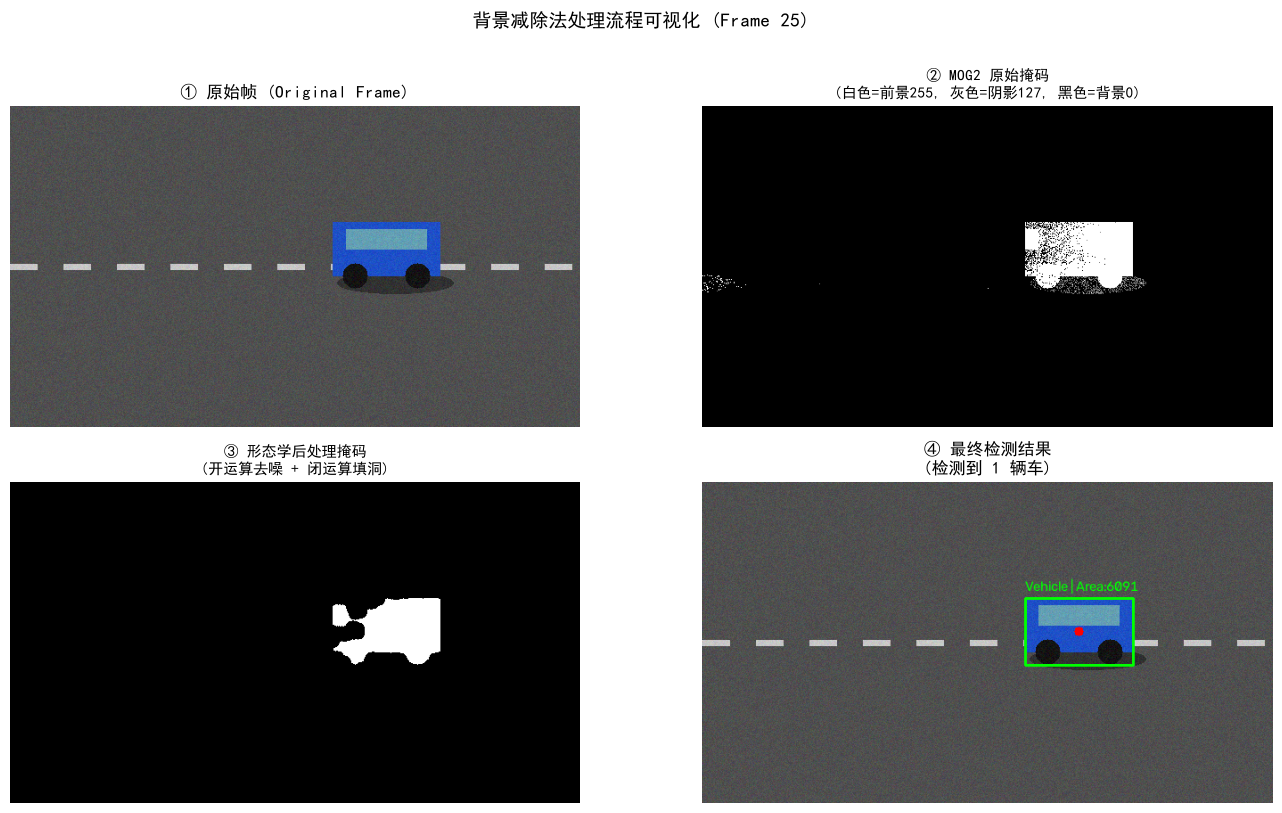

检测到车辆信息：
  边界框 (x, y, w, h): (362, 130, 121, 75)
  中心坐标: (422, 167)
  轮廓面积: 6091 像素平方


In [4]:
# 选取车辆位于画面中央的帧进行可视化
target_idx = 25
res_frame, raw_mask, clean_mask, vehicles = all_results[target_idx]
original_frame = synthetic_frames[target_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 子图1：原始帧
axes[0, 0].imshow(cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('① 原始帧 (Original Frame)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# 子图2：MOG2 原始掩码（含阴影）
axes[0, 1].imshow(raw_mask, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('② MOG2 原始掩码\n(白色=前景255, 灰色=阴影127, 黑色=背景0)', fontsize=11)
axes[0, 1].axis('off')

# 子图3：形态学处理后的清洁掩码
axes[1, 0].imshow(clean_mask, cmap='gray')
axes[1, 0].set_title('③ 形态学后处理掩码\n(开运算去噪 + 闭运算填洞)', fontsize=11)
axes[1, 0].axis('off')

# 子图4：最终检测结果
axes[1, 1].imshow(cv2.cvtColor(res_frame, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'④ 最终检测结果\n(检测到 {len(vehicles)} 辆车)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle(f'背景减除法处理流程可视化 (Frame {target_idx})', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

if vehicles:
    v = vehicles[0]
    print(f'检测到车辆信息：')
    print(f'  边界框 (x, y, w, h): {v["bbox"]}')
    print(f'  中心坐标: {v["center"]}')
    print(f'  轮廓面积: {v["area"]:.0f} 像素平方')

### 4.5 车辆轨迹追踪与速度估算

在获取每帧的车辆中心坐标后，可以通过追踪中心点的位移来估算车辆速度。这是 V-WIM 系统中提取车辆时空信息的关键步骤。


车辆速度估算结果（假设 1像素 = 0.05m，帧率 = 30.0FPS）：
  平均速度: 86.5 km/h
  最大速度: 129.6 km/h
  最小速度: 32.4 km/h


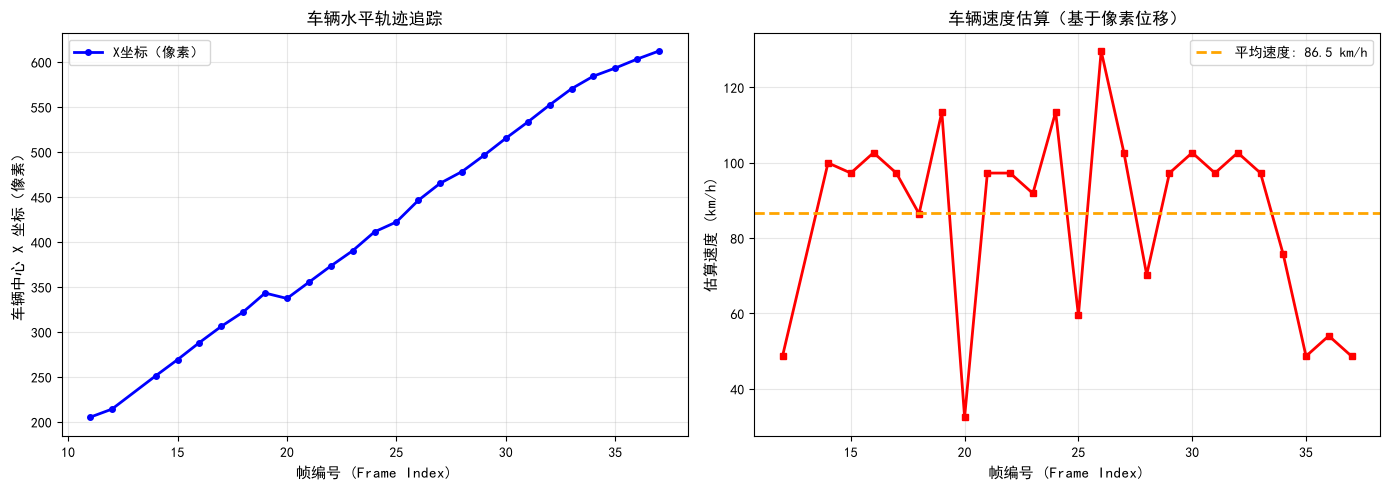

In [5]:
# 提取每帧检测到车辆的中心坐标
trajectory_x = []   # 车辆中心点 x 坐标（像素）
trajectory_y = []   # 车辆中心点 y 坐标（像素）
frame_indices = []  # 对应帧编号

for i, (_, _, _, veh_list) in enumerate(all_results):
    if veh_list:
        # 取面积最大的检测框（主车辆）
        main_vehicle = max(veh_list, key=lambda v: v['area'])
        cx, cy = main_vehicle['center']
        trajectory_x.append(cx)
        trajectory_y.append(cy)
        frame_indices.append(i)

# ---- 速度估算 ----
# 假设相机标定参数：1 像素 = 0.05 米（实际应通过相机标定获得）
# 假设视频帧率：30 FPS
PIXEL_TO_METER = 0.05   # 像素到米的转换系数（需根据实际相机标定）
FPS = 30.0              # 视频帧率

speeds = []       # 单位：km/h
speed_frames = []

for j in range(1, len(trajectory_x)):
    dx = trajectory_x[j] - trajectory_x[j-1]  # 像素位移
    dt = (frame_indices[j] - frame_indices[j-1]) / FPS  # 时间间隔（秒）
    if dt > 0:
        speed_mps = abs(dx) * PIXEL_TO_METER / dt  # 速度（m/s）
        speed_kmh = speed_mps * 3.6                 # 速度（km/h）
        speeds.append(speed_kmh)
        speed_frames.append(frame_indices[j])

# 可视化轨迹与速度
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 轨迹图
ax1.plot(frame_indices, trajectory_x, 'b-o', markersize=4, linewidth=2, label='X坐标（像素）')
ax1.set_xlabel('帧编号 (Frame Index)', fontsize=11)
ax1.set_ylabel('车辆中心 X 坐标（像素）', fontsize=11)
ax1.set_title('车辆水平轨迹追踪', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 速度图
if speeds:
    ax2.plot(speed_frames, speeds, 'r-s', markersize=4, linewidth=2)
    ax2.axhline(y=np.mean(speeds), color='orange', linestyle='--', linewidth=2,
                label=f'平均速度: {np.mean(speeds):.1f} km/h')
    ax2.set_xlabel('帧编号 (Frame Index)', fontsize=11)
    ax2.set_ylabel('估算速度 (km/h)', fontsize=11)
    ax2.set_title('车辆速度估算（基于像素位移）', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    print(f'\n车辆速度估算结果（假设 1像素 = {PIXEL_TO_METER}m，帧率 = {FPS}FPS）：')
    print(f'  平均速度: {np.mean(speeds):.1f} km/h')
    print(f'  最大速度: {np.max(speeds):.1f} km/h')
    print(f'  最小速度: {np.min(speeds):.1f} km/h')

plt.tight_layout()
plt.show()

### 4.6 虚拟线圈检测与过桥时刻记录

在实际 V-WIM 系统中，需要在视频中设置**虚拟线圈（Virtual Loop）**，对应桥梁下方安装应变传感器的断面位置。当车辆中心点穿越虚拟线圈时，记录精确的时间戳，用于后续与结构应变数据的时空同步。

[事件] 车辆穿越虚拟线圈！
  帧编号: 18
  时间戳: 0.6000 秒
  像素坐标: (322, 167)


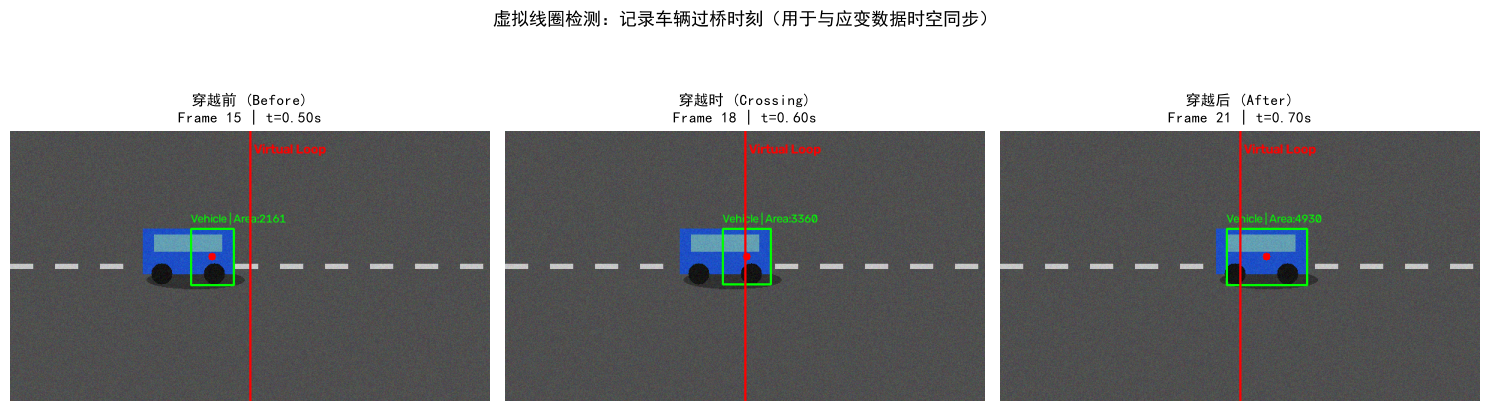

In [6]:
# 定义虚拟线圈位置（对应桥梁应变传感器断面的像素 x 坐标）
VIRTUAL_LOOP_X = 320  # 画面中央，假设对应桥梁跨中截面
FRAME_WIDTH = 640

# 检测车辆穿越虚拟线圈的时刻
crossing_events = []

for j in range(1, len(trajectory_x)):
    x_prev = trajectory_x[j-1]
    x_curr = trajectory_x[j]
    frame_curr = frame_indices[j]

    # 判断车辆中心点是否从左侧穿越了虚拟线圈
    if x_prev < VIRTUAL_LOOP_X <= x_curr:
        timestamp_s = frame_curr / FPS
        crossing_events.append({
            'frame': frame_curr,
            'timestamp_s': timestamp_s,
            'x_pixel': x_curr
        })
        print(f'[事件] 车辆穿越虚拟线圈！')
        print(f'  帧编号: {frame_curr}')
        print(f'  时间戳: {timestamp_s:.4f} 秒')
        print(f'  像素坐标: ({x_curr}, {trajectory_y[j]})')

# 可视化虚拟线圈检测
if crossing_events:
    cross_frame_idx = crossing_events[0]['frame']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for k, offset in enumerate([-3, 0, 3]):
        fidx = max(0, min(len(all_results)-1, cross_frame_idx + offset))
        display_frame = all_results[fidx][0].copy()

        # 绘制虚拟线圈（红色竖线）
        cv2.line(display_frame, (VIRTUAL_LOOP_X, 0), (VIRTUAL_LOOP_X, 360), (0, 0, 255), 2)
        cv2.putText(display_frame, 'Virtual Loop', (VIRTUAL_LOOP_X + 5, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        axes[k].imshow(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
        label = ['穿越前 (Before)', '穿越时 (Crossing)', '穿越后 (After)'][k]
        axes[k].set_title(f'{label}\nFrame {fidx} | t={fidx/FPS:.2f}s', fontsize=11)
        axes[k].axis('off')

    plt.suptitle('虚拟线圈检测：记录车辆过桥时刻（用于与应变数据时空同步）',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.7 模拟桥梁应变响应与荷载反演概念演示

以下代码模拟了桥梁在车辆荷载作用下的应变响应，并展示视觉系统与应变数据融合的概念。在真实系统中，应变数据来自安装在桥梁上的传感器。

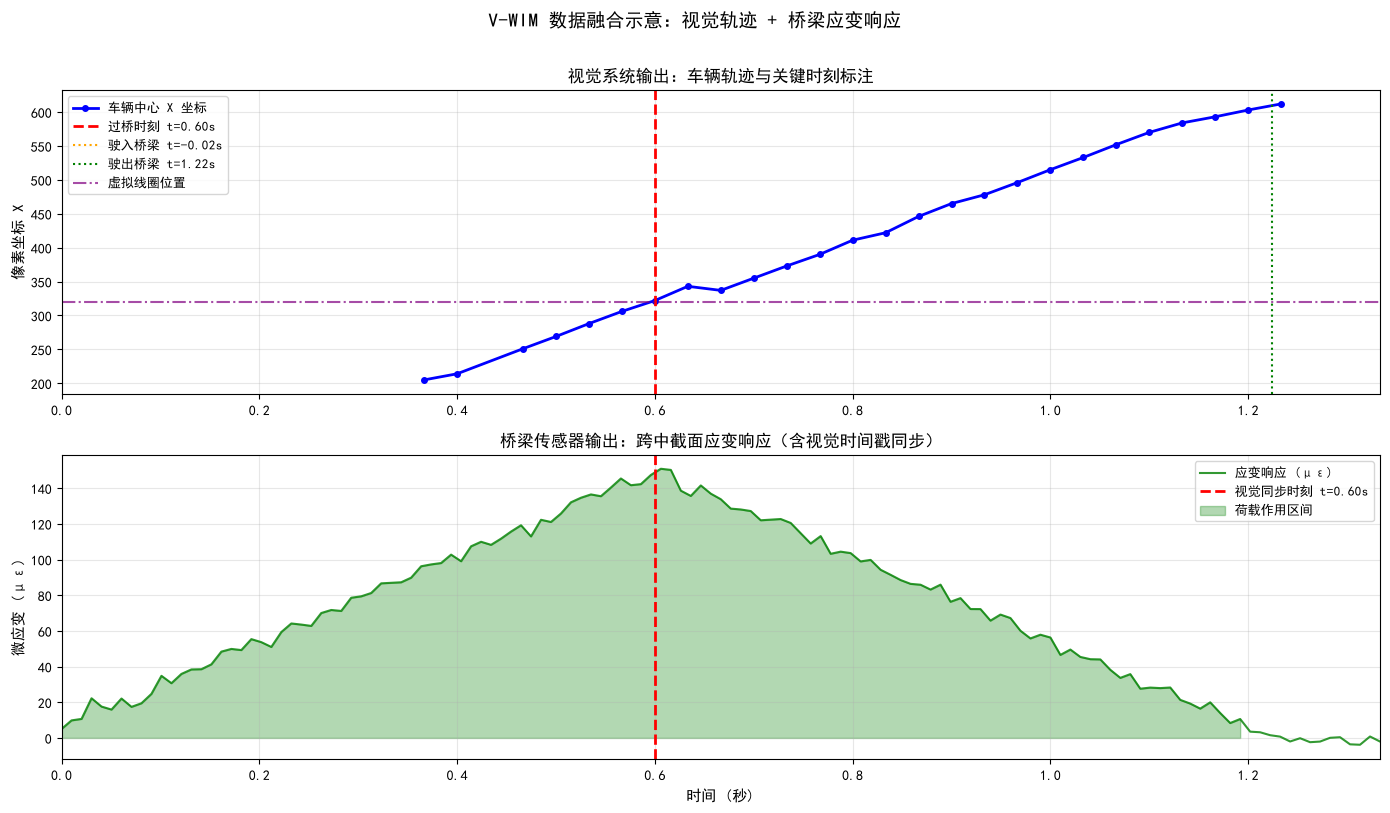


=== 荷载反演结果（概念演示）===
视觉系统提取的车辆速度: 86.5 km/h
车辆过桥时刻（虚拟线圈）: 0.600 s
桥梁应变峰值: 150.88 με
估算车辆荷载（简化）: 50.3 kN
注：实际荷载反演需结合完整的影响线矩阵和桥梁力学模型。


In [7]:
# ---- 模拟桥梁应变响应 ----
# 假设桥梁跨中截面的应变响应为车辆荷载的影响线函数

# 时间轴（秒），采样频率 100 Hz
sample_rate = 100  # Hz
total_time = len(synthetic_frames) / FPS  # 视频总时长（秒）
t_strain = np.linspace(0, total_time, int(total_time * sample_rate))

# 车辆过桥时刻（从视觉系统获取）
if crossing_events:
    t_cross = crossing_events[0]['timestamp_s']
else:
    t_cross = total_time / 2

# 车辆速度（m/s）
vehicle_speed_ms = np.mean(speeds) / 3.6 if speeds else 10.0
bridge_span = 30.0  # 桥梁跨径（米）
t_traverse = bridge_span / vehicle_speed_ms  # 车辆过桥时间（秒）

# 简支梁跨中弯矩影响线（三角形近似）
t_enter = t_cross - t_traverse / 2
t_exit = t_cross + t_traverse / 2

strain_signal = np.zeros_like(t_strain)
for idx_t, t in enumerate(t_strain):
    if t_enter <= t <= t_cross:
        strain_signal[idx_t] = (t - t_enter) / (t_cross - t_enter) * 150
    elif t_cross < t <= t_exit:
        strain_signal[idx_t] = (t_exit - t) / (t_exit - t_cross) * 150

# 添加传感器噪声
strain_signal += np.random.normal(0, 3, len(strain_signal))

# ---- 可视化数据融合 ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# 上图：车辆轨迹（视觉系统输出）
time_visual = [fi / FPS for fi in frame_indices]
ax1.plot(time_visual, trajectory_x, 'b-o', markersize=4, linewidth=2, label='车辆中心 X 坐标')
ax1.axvline(x=t_cross, color='red', linestyle='--', linewidth=2, label=f'过桥时刻 t={t_cross:.2f}s')
ax1.axvline(x=t_enter, color='orange', linestyle=':', linewidth=1.5, label=f'驶入桥梁 t={t_enter:.2f}s')
ax1.axvline(x=t_exit, color='green', linestyle=':', linewidth=1.5, label=f'驶出桥梁 t={t_exit:.2f}s')
ax1.axhline(y=VIRTUAL_LOOP_X, color='purple', linestyle='-.', linewidth=1.5, alpha=0.7, label='虚拟线圈位置')
ax1.set_ylabel('像素坐标 X', fontsize=11)
ax1.set_title('视觉系统输出：车辆轨迹与关键时刻标注', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, total_time])

# 下图：桥梁应变响应（传感器输出）
ax2.plot(t_strain, strain_signal, 'g-', linewidth=1.5, alpha=0.8, label='应变响应 (με)')
ax2.axvline(x=t_cross, color='red', linestyle='--', linewidth=2, label=f'视觉同步时刻 t={t_cross:.2f}s')
ax2.fill_between(t_strain, strain_signal, 0, where=(strain_signal > 5),
                  alpha=0.3, color='green', label='荷载作用区间')
ax2.set_xlabel('时间 (秒)', fontsize=11)
ax2.set_ylabel('微应变 (με)', fontsize=11)
ax2.set_title('桥梁传感器输出：跨中截面应变响应（含视觉时间戳同步）', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, total_time])

plt.suptitle('V-WIM 数据融合示意：视觉轨迹 + 桥梁应变响应', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 简单荷载估算（概念演示）
peak_strain = np.max(strain_signal)
EI_simplified = 2.5e6   # 简化刚度系数（kN·m²）
influence_coeff = bridge_span / 4  # 简支梁跨中弯矩影响线峰值（m）
estimated_load_kN = (peak_strain * 1e-6 * EI_simplified) / influence_coeff

print('\n=== 荷载反演结果（概念演示）===')
print(f'视觉系统提取的车辆速度: {vehicle_speed_ms*3.6:.1f} km/h')
print(f'车辆过桥时刻（虚拟线圈）: {t_cross:.3f} s')
print(f'桥梁应变峰值: {peak_strain:.2f} με')
print(f'估算车辆荷载（简化）: {estimated_load_kN:.1f} kN')
print('注：实际荷载反演需结合完整的影响线矩阵和桥梁力学模型。')

---

## 5. 关键参数调优指南

MOG2 算法的性能对参数设置较为敏感，以下是针对交通监测场景的调优建议：

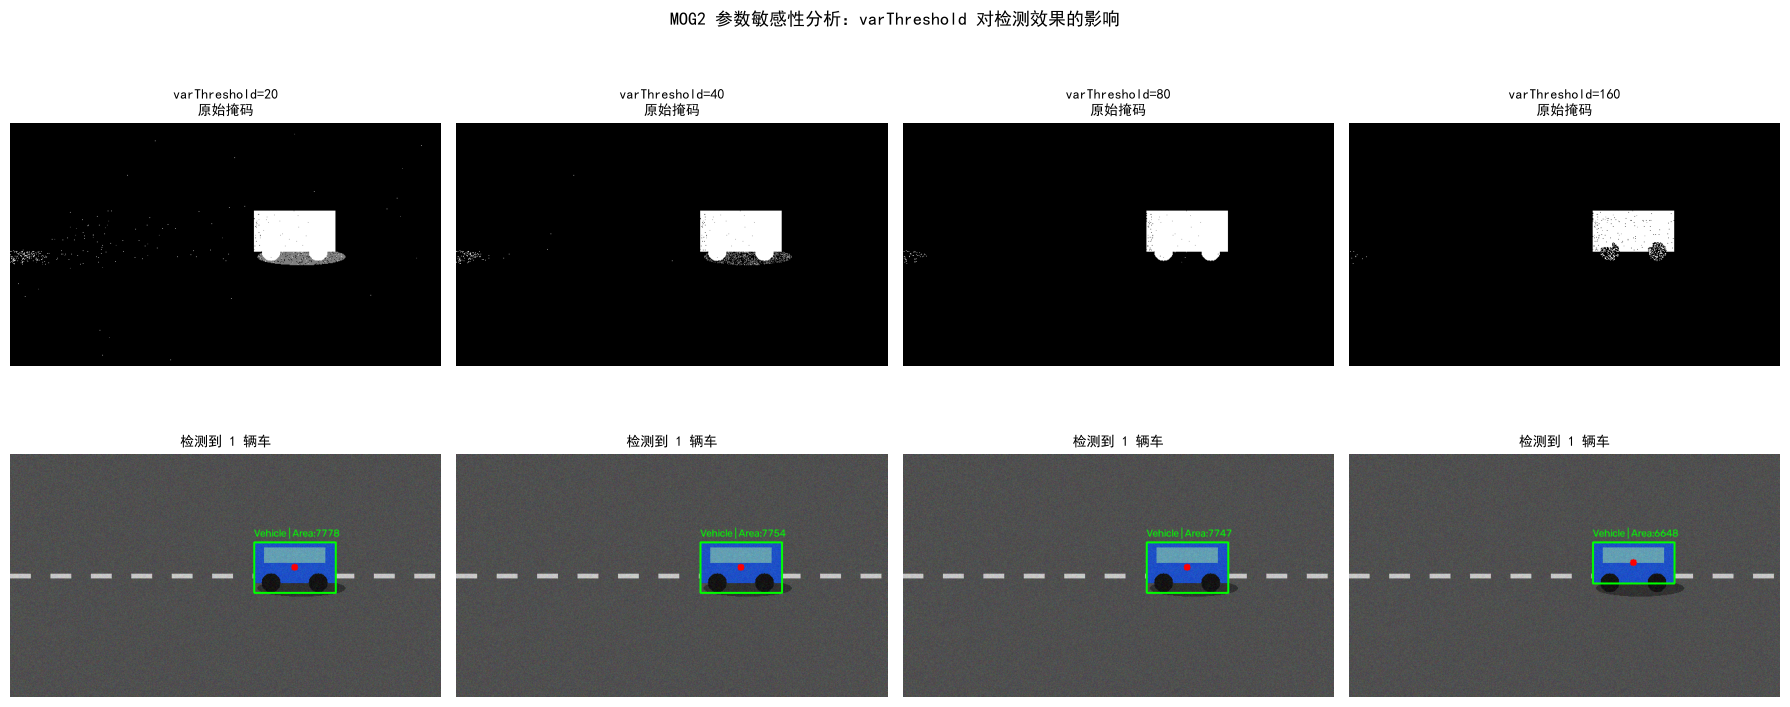

参数调优建议：
  varThreshold 较小（如20）：对变化敏感，易产生噪声误检
  varThreshold 适中（如40-60）：推荐值，平衡检测率与误检率
  varThreshold 较大（如80+）：不敏感，可能漏检颜色接近背景的车辆


In [8]:
# 参数敏感性分析：对比不同 varThreshold 的检测效果
test_thresholds = [20, 40, 80, 160]
test_frame = synthetic_frames[25]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, threshold in enumerate(test_thresholds):
    # 重新初始化检测器（不同阈值）
    test_detector = VehicleDetector(
        history=300, var_threshold=threshold, detect_shadows=True, min_area=800
    )
    # 需要先用前几帧建立背景模型
    for warmup_frame in synthetic_frames[:20]:
        test_detector.process(warmup_frame)

    # 处理目标帧
    res_f, raw_m, clean_m, vehs = test_detector.process(test_frame)

    axes[0, col].imshow(raw_m, cmap='gray')
    axes[0, col].set_title(f'varThreshold={threshold}\n原始掩码', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(cv2.cvtColor(res_f, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f'检测到 {len(vehs)} 辆车', fontsize=10)
    axes[1, col].axis('off')

plt.suptitle('MOG2 参数敏感性分析：varThreshold 对检测效果的影响',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('参数调优建议：')
print('  varThreshold 较小（如20）：对变化敏感，易产生噪声误检')
print('  varThreshold 适中（如40-60）：推荐值，平衡检测率与误检率')
print('  varThreshold 较大（如80+）：不敏感，可能漏检颜色接近背景的车辆')

---

## 6. 总结与展望

本文系统介绍了背景减除法（尤其是 MOG2 算法）在动态车辆荷载监测中的应用，并通过 Python 代码演示了从车辆检测、轨迹追踪、速度估算到虚拟线圈触发的完整视觉处理流程。

### 6.1 方法优势

MOG2 背景减除法在交通监测场景中具有以下显著优势：

- **自适应性强：** 能够自动适应光照渐变、背景扰动等复杂场景变化。
- **计算效率高：** 相比深度学习方法，MOG2 对硬件要求低，可在嵌入式设备上实时运行。
- **轮廓提取完整：** 能够获取完整的车辆像素级轮廓，有利于后续的几何特征提取。
- **阴影抑制：** 内置阴影检测机制，有效避免阴影导致的车辆形状畸变。

### 6.2 局限性与改进方向

| 局限性 | 改进方向 |
|--------|----------|
| 极端天气（大雨、暴雪）下性能下降 | 结合红外摄像机或激光雷达（LiDAR）多模态融合 |
| 严重光照突变（如隧道出入口）导致误检 | 自适应阈值调整 + 时域滤波 |
| 车辆严重遮挡时难以分割 | 引入深度学习目标检测（YOLO）+ 多目标跟踪（DeepSORT） |
| 仅提供像素坐标，需相机标定转换 | 精确的相机标定与透视变换（Homography） |
| 无法识别车型与轴数 | 结合车辆关键点检测（Keypoint Detection）识别车轴 |

### 6.3 未来展望

随着人工智能技术的持续演进，未来的 V-WIM 系统将逐步融合深度学习目标检测（如 YOLOv8）、多目标跟踪算法（如 ByteTrack）以及基于关键点的车轴识别方法，在更复杂的交通场景下实现更高精度的车辆时空信息提取，最终支撑更精准的动态荷载反演，为桥梁结构健康监测提供更可靠的数据基础。

---

## 参考文献

[1] Yang, J., et al. "Computer Vision-Based Real-Time Identification of Vehicle Loads for Bridge Structural Health Monitoring." *Sustainability* 16.3 (2024): 1081. https://www.mdpi.com/2071-1050/16/3/1081

[2] Lam, P.T., et al. "A vision-based weigh-in-motion approach for vehicle load tracking." *Structural Control and Health Monitoring* (2025). https://www.sciencedirect.com/science/article/pii/S1093968726000307

[3] Zivkovic, Z. "Improved adaptive Gaussian mixture model for background subtraction." *Proceedings of the 17th International Conference on Pattern Recognition (ICPR)*, 2004.

[4] OpenCV Documentation: Background Subtraction. https://docs.opencv.org/4.x/d1/dc5/tutorial_background_subtraction.html

[5] Zhang, T., et al. "Roadside LiDAR Vehicle Detection and Tracking Using Range and Intensity Background Subtraction." *arXiv preprint arXiv:2201.04756* (2022). https://arxiv.org/abs/2201.04756